# What an echo train costs

[`01_build.ipynb`](01_build.ipynb) turned 4.3 minutes into 18 seconds and asserted that k is exact
at every one of 128 echoes. It could not say what was *paid* for that, because everything paid is a
property of the magnetisation.

| | |
|---|---|
| **1. the echo envelope** | at a perfect 180 it is exactly $e^{-t/T_2}$; at `B1 = 0.8` it is not, and what it becomes is the SAR cost of a real train |
| **2. blurring** | echo index sets the T2 weighting, so an ordering is a **filter across $k_y$** and therefore a point-spread function |
| **3. two knobs** | turbo factor moves the blur; echo index moves the contrast. Both live in `segments` |
| **4. the ghost** | a *periodic* modulation of $k_y$ is a **replica of the object**, not a blur — and `linear` is periodic by construction |
| **5. HASTE** | 72 echoes in 0.8 s, partial Fourier and POCS |

## This notebook simulates one voxel, not a brain

**Every measurement here is made on a single-spin phantom, and that is not a shortcut — it is the
right instrument.** A ghost is a periodic modulation of k-space and a blur is a smooth one, so both
live in $S(k_y)$; the k-space of a *point* object **is** that modulation, with no object structure
on top of it and no reconstruction in between. It costs **1.3 s** per sequence against **173 s** for
the same acquisition on a 128 × 128 × 4 phantom, which is also what makes this notebook safe to run.

Images still earn their place — §4 draws the three orderings and §5 reconstructs HASTE — but they
are **illustration of a measurement already made**. Two slices rather than four and
`SIM_THREADS = 4` bring them to about **four minutes**; `BRAIN_IMAGES = False` skips them and loses
no number.

**Needs `seqcraft[sim,recon]`** and the same BrainWeb phantom `gre_2d/02` downloads into
`examples/data/`.

In [1]:
import os

# Set before torch is imported, which is where it reads them.  MRzero's inner loop is dense
# complex linear algebra and it will take every core it is offered: on a 32-core machine the
# default of 16 threads is minutes of saturated CPU, and this notebook does not need it.
SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

import tempfile
import time
import urllib.request
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import pypulseq as pp
import torch

import seqcraft as sc

torch.set_num_threads(SIM_THREADS)
plt.rcParams['figure.dpi'] = 56

#: Draw the 16-echo trains against the BrainWeb slab.  Three sequences at ~80 s each, plus HASTE
#: at ~3 s.  Every *number* in this notebook is measured on one spin, so False costs only pictures.
BRAIN_IMAGES = True

#: Slices in the slab.  ``gre_2d/02`` uses four, because a phantom one voxel thick reads a
#: slice-select gradient as complete dephasing and returns exactly zero signal.  Two is enough for
#: the gradient to have something to dephase across, for half the voxels and half the time.
NZ = 2

SEQ_DIR = Path('seq')
nominal = np.load(SEQ_DIR / 'fse_2d_nominal.npz')

MATRIX = tuple(int(v) for v in nominal['matrix'])
FOV_MM = tuple(float(v) for v in nominal['fov_mm'])
THICKNESS_MM = float(nominal['thickness_mm'])
CENTER_LINE = int(nominal['center_line'])
NX, NY = MATRIX
NAMES = [str(v) for v in nominal['names']]
NOISE_SNR = 60

meta = {name: {key: float(nominal[f'{key}_{name}'])
               for key in ('echoes', 'shots', 'dummy_shots', 'te_eff_s', 'echo_spacing_s',
                           'partial_fourier', 'num_samples', 'pre_echo_samples')}
        for name in NAMES}
ECHOES = int(meta['fse_interleaved']['echoes'])
SHOTS = int(meta['fse_interleaved']['shots'])
ECHO_SPACING_S = meta['fse_interleaved']['echo_spacing_s']

opts = pp.Opts(
    max_grad=32, grad_unit='mT/m',
    max_slew=130, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
)
grad_raster = sc.Raster(opts.grad_raster_time)

exc = sc.modules.Excitation(opts=opts, flip_deg=90.0, thickness_mm=THICKNESS_MM,
                            duration_s=float(nominal['excite_duration_s']))
refoc = sc.modules.Refocusing(
    opts=opts, thickness_mm=THICKNESS_MM * float(nominal['refocus_factor']),
    duration_s=float(nominal['refocus_duration_s']),
    crush_cycles_per_voxel=float(nominal['crush_cycles_slice']), crush_voxel_mm=THICKNESS_MM)

for name in NAMES:
    row = meta[name]
    print(f'{name:16s} {int(row["echoes"]):3d} echoes x {int(row["shots"]):3d} shots '
          f'+ {int(row["dummy_shots"])} dummy   te_eff {row["te_eff_s"] * 1e3:7.3f} ms')
print()
print(f'{torch.get_num_threads()} simulation threads of {os.cpu_count()} cores.')
print(f'Budget: ~15 s of one-voxel measurement, and BRAIN_IMAGES = {BRAIN_IMAGES}'
      f'{" -- about 4 minutes of images on top" if BRAIN_IMAGES else " -- no images"}.')

D:\MIniconda\envs\NUM\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


D:\MIniconda\envs\NUM\Lib\site-packages\sigpy\config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
DLL load failed while importing cudnn: The specified module could not be found.
  warnings.warn(


fse_interleaved   16 echoes x   8 shots + 1 dummy   te_eff  96.302 ms
fse_linear        16 echoes x   8 shots + 1 dummy   te_eff  10.702 ms
fse_centric       16 echoes x   8 shots + 1 dummy   te_eff  10.702 ms
haste             72 echoes x   1 shots + 0 dummy   te_eff  95.585 ms

4 simulation threads of 32 cores.
Budget: ~15 s of one-voxel measurement, and BRAIN_IMAGES = True -- about 4 minutes of images on top.


---
## 1. The echo envelope, measured

A CPMG probe: one 90, then `echoes` refocusing pulses at the sequence's own echo spacing, with an
ADC at each echo. **No encoding at all** — the question is the amplitude. `Refocusing`'s own crusher
pair is kept, because it is what dephases the FID an imperfect 180 leaves behind.

In [2]:
def cpmg(echoes, *, refoc_phase_deg=0.0):
    """One 90 and `echoes` refocused echoes, with an ADC straddling each one."""
    tree = sc.LogicBlock('cpmg').add(0.0, exc(phase_deg=90.0))
    first = float(grad_raster.ceil(
        exc.time_to_center() + ECHO_SPACING_S / 2 - refoc.time_to_center()))
    for n in range(echoes):
        tree.add(first + n * ECHO_SPACING_S, refoc(phase_deg=refoc_phase_deg))
        tree.add(float(grad_raster.ceil(
            exc.time_to_center() + (n + 1) * ECHO_SPACING_S - 4e-5)),
            pp.make_adc(num_samples=8, dwell=1e-5, delay=1e-5, system=opts))
    return tree


def spin(*, t1_s, t2_s, t2dash_s, b1=1.0, voxel_mm=None):
    """One spin of one tissue.  Floats, not numpy scalars -- see ../se_2d/02 for why."""
    built = mr0.CustomVoxelPhantom(
        pos=[[0.0, 0.0, 0.0]], PD=[1.0], T1=[float(t1_s)], T2=[float(t2_s)],
        T2dash=[float(t2dash_s)], D=[0.0],
        voxel_size=(THICKNESS_MM if voxel_mm is None else voxel_mm) / 1e3, voxel_shape='box',
    ).build()
    built.B0 = built.B0.float()
    built.B1 = built.B1.float() * 0 + float(b1)
    return built


def simulate(seq, phantom, *, states=200):
    """Run one imported sequence and hand back the raw signal, freeing the graph after."""
    graph = mr0.compute_graph(seq, phantom, max_state_count=states, min_state_mag=1e-4)
    signal = np.asarray(mr0.execute_graph(graph, seq, phantom, min_emitted_signal=1e-4,
                                          min_latent_signal=1e-5, print_progress=False))
    del graph
    return signal


def echo_train(echoes, phantom, **kwargs):
    """The magnitude at each echo, straight out of the raw ADC signal."""
    with tempfile.TemporaryDirectory(prefix='fse-probe-') as scratch:
        path = Path(scratch) / 'cpmg.seq'
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', sc.SeqCraftWarning)
            sc.compile(cpmg(echoes, **kwargs), opts, name='cpmg').write(str(path))
        signal = simulate(mr0.Sequence.import_file(str(path)), phantom, states=400)[:, 0]
    return np.abs(signal.reshape(echoes, 8)).max(axis=1)


def decay_s(series, t=None):
    """The time constant of an envelope, by a straight-line fit to log S."""
    t = (1 + np.arange(len(series))) * ECHO_SPACING_S if t is None else t
    return -1.0 / np.polyfit(t, np.log(series), 1)[0]


TISSUES = {
    'white matter': dict(t1_s=0.86, t2_s=0.080, t2dash_s=0.030),
    'grey matter': dict(t1_s=1.58, t2_s=0.100, t2dash_s=0.040),
}
times = (1 + np.arange(ECHOES)) * ECHO_SPACING_S
envelope = {name: echo_train(ECHOES, spin(**tissue)) for name, tissue in TISSUES.items()}
imperfect = {b1: echo_train(ECHOES, spin(**TISSUES['white matter'], b1=b1))
             for b1 in (1.0, 0.9, 0.8, 0.7)}

print(f'{"tissue":14s} {"T2 truth":>9s} {"envelope fit":>13s}')
for name, tissue in TISSUES.items():
    print(f'{name:14s} {tissue["t2_s"] * 1e3:8.1f}ms {decay_s(envelope[name]) * 1e3:12.1f}ms')
print('\nA perfect train decays at exactly T2, which is what makes the echo index a *clean* T2')
print('filter across ky -- the whole basis of section 2.\n')

print(f'{"B1":>5s} {"flip":>7s} {"effective decay":>16s} {"signal at te_eff":>18s}')
for b1, series in imperfect.items():
    print(f'{b1:5.1f} {b1 * 180:6.0f}d {decay_s(series) * 1e3:15.1f}ms '
          f'{series[ECHOES // 2 - 1] / imperfect[1.0][ECHOES // 2 - 1]:18.3f}')
print('\nAn imperfect refocusing angle does not lose a fixed fraction -- it loses one *per echo*,')
print('so a 20 % B1 error costs 57 % of the signal by the eighth.  That is the SAR trade a')
print('120-150 degree train makes, and it is why flip_deg is an argument on Refocusing.\n')

sweep = [echo_train(ECHOES, spin(**TISSUES['white matter'], b1=0.8), refoc_phase_deg=phase)
         for phase in (0.0, 45.0, 90.0)]
print(f'refocusing phase swept 0 -> 90 degrees at B1 = 0.8: worst amplitude change '
      f'{max(np.abs(s - sweep[0]).max() for s in sweep):.1e}')
print('MRzero refocuses each echo from a single configuration state, so the phase of the pulse')
print('relative to the excitation does not reach the magnitude.  On a scanner it does.  Not')
print('measured here -- named, like the crusher balance in ../se_2d/02.')

tissue          T2 truth  envelope fit
white matter       80.0ms         80.0ms
grey matter       100.0ms        100.0ms

A perfect train decays at exactly T2, which is what makes the echo index a *clean* T2
filter across ky -- the whole basis of section 2.

   B1    flip  effective decay   signal at te_eff
  1.0    180d            80.0ms              1.000
  0.9    162d            67.5ms              0.810
  0.8    144d            45.7ms              0.426
  0.7    126d            29.4ms              0.141

An imperfect refocusing angle does not lose a fixed fraction -- it loses one *per echo*,
so a 20 % B1 error costs 57 % of the signal by the eighth.  That is the SAR trade a
120-150 degree train makes, and it is why flip_deg is an argument on Refocusing.



refocusing phase swept 0 -> 90 degrees at B1 = 0.8: worst amplitude change 0.0e+00
MRzero refocuses each echo from a single configuration state, so the phase of the pulse
relative to the excitation does not reach the magnitude.  On a scanner it does.  Not
measured here -- named, like the crusher balance in ../se_2d/02.


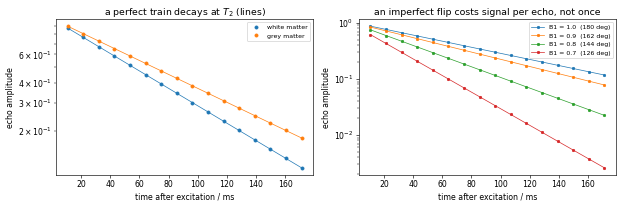

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.8))
for index, (name, tissue) in enumerate(TISSUES.items()):
    axes[0].semilogy(times * 1e3, envelope[name], 'o', ms=4, color=f'C{index}', label=name)
    axes[0].semilogy(times * 1e3, envelope[name][0] * np.exp(-(times - times[0]) / tissue['t2_s']),
                     '-', lw=0.9, color=f'C{index}')
axes[0].set(xlabel='time after excitation / ms', ylabel='echo amplitude',
            title='a perfect train decays at $T_2$ (lines)')
axes[0].legend(fontsize=8)
for index, (b1, series) in enumerate(imperfect.items()):
    axes[1].semilogy(times * 1e3, series, 'o-', ms=3, lw=0.9, color=f'C{index}',
                     label=f'B1 = {b1:.1f}  ({b1 * 180:.0f} deg)')
axes[1].set(xlabel='time after excitation / ms', ylabel='echo amplitude',
            title='an imperfect flip costs signal per echo, not once')
axes[1].legend(fontsize=8)
fig.tight_layout()

---
## 2. What the table does to $k_y$

Every line of k-space is acquired at a different point on that envelope, and **which** point is what
the table decides. So an ordering is a multiplicative filter across $k_y$, and the image is
convolved with its transform.

One spin at isocentre, through the `.seq` files `01` wrote, gridded by the `LIN` labels read back
out of them. A point object's k-space is flat, so **what comes back is the filter itself** — 1.3 s
per sequence, and nothing between the physics and the number.

In [4]:
def lin_labels(path):
    """The LIN label of every acquired readout, read back out of the written file."""
    seq = pp.Sequence(system=opts)
    seq.read(str(path))
    return [int(v) for v in np.atleast_1d(np.asarray(
        seq.evaluate_labels(evolution='adc')['LIN']))]


def acquire(name, phantom):
    """Import the written .seq, simulate it, and grid it by the labels it carries."""
    path = SEQ_DIR / f'{name}.seq'
    lines = lin_labels(path)
    samples = int(meta[name]['num_samples'])
    signal = simulate(mr0.Sequence.import_file(str(path)), phantom)
    per_readout = signal.reshape(len(lines), samples, -1)
    grid = np.zeros((per_readout.shape[2], NY, NX), dtype=np.complex64)
    # Partial Fourier drops samples from the *pre-echo* side, so the window lands at
    # NX//2 - pre_echo_samples rather than at zero.
    start = NX // 2 - int(meta[name]['pre_echo_samples'])
    grid[:, list(lines), start:start + samples] = per_readout.transpose(2, 0, 1)
    mask = np.zeros(NY, dtype=bool)
    mask[list(lines)] = True
    return mask, grid


def ifft2c(ksp):
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(ksp, axes=(-2, -1)), norm='ortho'),
                           axes=(-2, -1))


def rss(image):
    return np.sqrt((np.abs(image) ** 2).sum(0))


def fwhm_px(profile):
    """Full width at half maximum of a peak, by linear interpolation on each side."""
    peak = int(np.argmax(profile))
    half = profile[peak] / 2

    def edge(step):
        i = peak
        while 0 < i + step < len(profile) - 1 and profile[i + step] > half:
            i += step
        span = profile[i] - profile[i + step]
        return i + step * (profile[i] - half) / span if span else float(i)

    return edge(1) - edge(-1)


def outside_the_core(profile, core_px=4):
    """Fraction of a point spread's energy further than `core_px` from its peak.

    A blur keeps its energy in the core; a **replica** puts it somewhere else entirely, and this is
    the one number that tells the two apart without knowing where to look for the replica.
    """
    peak = int(np.argmax(profile))
    core = np.abs(np.arange(len(profile)) - peak) <= core_px
    return float(profile[~core].sum() / profile.sum())


point = spin(**TISSUES['white matter'], voxel_mm=FOV_MM[0] / NX)
ky_filter, psf = {}, {}
for name in NAMES:
    _, grid = acquire(name, point)
    ky_filter[name] = np.abs(grid[0, :, NX // 2])
    profile = np.abs(ifft2c(grid)[0])[:, NX // 2]
    psf[name] = profile / profile.max()

print(f'{"file":16s} {"te_eff":>9s} {"PSF FWHM":>10s} {"blur":>8s} {"outside the core":>17s}')
for name in ('fse_interleaved', 'fse_centric', 'fse_linear', 'haste'):
    print(f'{name:16s} {meta[name]["te_eff_s"] * 1e3:8.3f}ms {fwhm_px(psf[name]):9.2f}px '
          f'{fwhm_px(psf[name]) * FOV_MM[1] / NY:7.2f}mm {outside_the_core(psf[name]):17.3f}')
print()
print('interleaved keeps each echo index in a contiguous band of ky, so its filter is a smooth')
print('staircase and its point spread is one lobe.  centric puts the least-decayed echoes at the')
print('centre -- the widest lobe and the most signal.  linear puts two thirds of its energy')
print('outside its own core, and section 4 is what that is.')

file                te_eff   PSF FWHM     blur  outside the core
fse_interleaved    96.302ms      1.43px    2.86mm             0.398
fse_centric        10.702ms      1.84px    3.69mm             0.149
fse_linear         10.702ms      1.10px    2.19mm             0.662
haste              95.585ms      9.49px   18.98mm             0.686

interleaved keeps each echo index in a contiguous band of ky, so its filter is a smooth
staircase and its point spread is one lobe.  centric puts the least-decayed echoes at the
centre -- the widest lobe and the most signal.  linear puts two thirds of its energy
outside its own core, and section 4 is what that is.


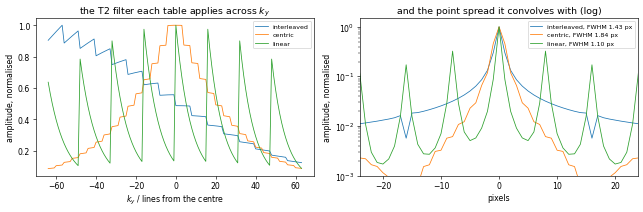

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 3.9))
for name in ('fse_interleaved', 'fse_centric', 'fse_linear'):
    label = name.replace('fse_', '')
    axes[0].plot(np.arange(NY) - CENTER_LINE, ky_filter[name] / ky_filter[name].max(),
                 lw=1.0, label=label)
    axes[1].semilogy(np.arange(NY) - NY // 2, np.maximum(psf[name], 1e-4), lw=1.0,
                     label=f'{label}, FWHM {fwhm_px(psf[name]):.2f} px')
axes[0].set(xlabel='$k_y$ / lines from the centre', ylabel='amplitude, normalised',
            title='the T2 filter each table applies across $k_y$')
axes[0].legend(fontsize=8)
axes[1].set(xlabel='pixels', ylabel='amplitude, normalised', xlim=(-24, 24), ylim=(1e-3, 1.5),
            title='and the point spread it convolves with (log)')
axes[1].legend(fontsize=8)
fig.tight_layout()

`linear` is the one `01` warned about, and the log axis is where it shows: its filter is a
**sawtooth** of period 16 lines, so its point spread carries discrete replicas at multiples of
8 pixels rather than a wider lobe. That is a ghost, and §4 is where it gets a number.

**The three effective TEs are not the same, and that is a property of the orderings.** Centric
acquires $k=0$ at the first echo by construction — that is what centric *means*. Holding `te_eff`
fixed while the ordering varies needs a fourth table; §3 does that comparison arithmetically
instead, from one measured envelope.

---
## 3. Contrast and blurring are two knobs, not one

The envelope in §1 was measured; the mapping from echo index to $k_y$ is arithmetic. So the PSF of
any table can be computed without another simulation, and the two knobs separated: **hold the
effective TE and raise the turbo factor** (same contrast, more blurring, less time), or **hold the
turbo factor and move the effective TE** (same blurring, different contrast).

In [6]:
def interleaved(echoes, ny=NY):
    shots = ny // echoes
    return [[s + n * shots for n in range(echoes)] for s in range(shots)]


def rolled(segments, echo_of_centre):
    """The same shots, dealt so that `echo_of_centre` is the echo acquiring CENTER_LINE."""
    here = next(s.index(CENTER_LINE) for s in segments if CENTER_LINE in s)
    return [s[(here - echo_of_centre) % len(s):] + s[:(here - echo_of_centre) % len(s)]
            for s in segments]


def predicted_psf(segments, series):
    """The ky filter a table applies to a measured envelope, and its transform."""
    ky = np.zeros(NY)
    for shot in segments:
        for echo, line in enumerate(shot):
            ky[line] = series[echo]
    return np.abs(np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(ky))))


white, grey = envelope['white matter'], envelope['grey matter']
long_white = echo_train(32, spin(**TISSUES['white matter']))
long_grey = echo_train(32, spin(**TISSUES['grey matter']))
echo_at_96ms = int(round(0.096 / ECHO_SPACING_S)) - 1

print('same effective TE, different turbo factor')
print(f'{"turbo":>6s} {"shots":>6s} {"te_eff":>9s} {"PSF FWHM":>10s} {"grey/white":>11s}')
for turbo in (16, 32):
    # A turbo factor below echo_at_96ms + 1 cannot put k = 0 on that echo at all, so there is no
    # table for it at this effective TE and the row would be a different measurement.
    assert turbo > echo_at_96ms and NY % turbo == 0
    table = rolled(interleaved(turbo), echo_at_96ms)
    print(f'{turbo:6d} {NY // turbo:6d} {(echo_at_96ms + 1) * ECHO_SPACING_S * 1e3:8.3f}ms '
          f'{fwhm_px(predicted_psf(table, long_white[:turbo])):9.2f}px '
          f'{long_grey[echo_at_96ms] / long_white[echo_at_96ms]:11.3f}')

print('\nsame turbo factor, different effective TE')
print(f'{"turbo":>6s} {"echo":>5s} {"te_eff":>9s} {"PSF FWHM":>10s} {"grey/white":>11s}')
for echo in (0, 3, 8, 15):
    table = rolled(interleaved(16), echo)
    print(f'{16:6d} {echo:5d} {(echo + 1) * ECHO_SPACING_S * 1e3:8.3f}ms '
          f'{fwhm_px(predicted_psf(table, white)):9.2f}px '
          f'{grey[echo] / white[echo]:11.3f}')
print('\nThe turbo factor moves the width and leaves the ratio alone; the echo index moves the')
print('ratio and leaves the width alone.  Two knobs, and `segments` is where both of them live.')

same effective TE, different turbo factor
 turbo  shots    te_eff   PSF FWHM  grey/white
    16      8   96.300ms      1.48px       1.272
    32      4   96.300ms      2.52px       1.272

same turbo factor, different effective TE
 turbo  echo    te_eff   PSF FWHM  grey/white
    16     0   10.700ms      1.48px       1.027
    16     3   42.800ms      1.48px       1.113
    16     8   96.300ms      1.48px       1.272
    16    15  171.200ms      1.48px       1.534

The turbo factor moves the width and leaves the ratio alone; the echo index moves the
ratio and leaves the width alone.  Two knobs, and `segments` is where both of them live.


---
## 4. The ghost, and where the run-in went

A **periodic** modulation of $k_y$ is a replica of the object at `FOV / period`, not a blur. A
segmented train has two sources of one, at different periods:

| source | period in $k_y$ | replica at | fix |
|---|---|---|---|
| **`linear` ordering** scatters each echo index across k-space | `echoes` = 16 lines | 8 px = FOV/16 | a different table |
| **shot 0 starts from equilibrium** and the other seven do not | `shots` = 8 lines | 16 px = FOV/8 | `dummy_shots` |

The first is the table's and no run-in touches it. The second is **invisible to every check in
`01`** — the k-space *positions* are exact to $10^{-7}$ 1/m, and it is the *amplitudes* that differ
— which is why `01` builds every multi-shot file with `DUMMY_SHOTS = 1`. It does not arise in HASTE
at all, because one shot cannot be inconsistent with anything.

The measurement is the comb itself: shot 0 acquires lines $0, 8, 16, \ldots$, so comparing those
against the other seven shots' lines is the modulation depth, with no image and no reconstruction in
between — and it is what says whether the run-in did its job.

In [7]:
def comb_depth(name, period=SHOTS):
    """How much brighter shot 0's lines are than the rest -- the modulation, straight off ky."""
    magnitude = ky_filter[name]
    own = magnitude[0::period][magnitude[0::period] > 0].mean()
    rest = np.array([magnitude[s::period][magnitude[s::period] > 0].mean()
                     for s in range(1, period)])
    return float(own / rest.mean() - 1)


print(f'{"file":16s} {"dummy":>6s} {"shot 0 vs the rest":>19s} {"PSF at 16px":>12s} '
      f'{"PSF at 8px":>11s}')
for name in ('fse_interleaved', 'fse_centric', 'fse_linear'):
    print(f'{name:16s} {int(meta[name]["dummy_shots"]):6d} {comb_depth(name):18.2%} '
          f'{psf[name][NY // 2 + 16]:12.4f} {psf[name][NY // 2 + 8]:11.4f}')
print()
print(f'With one TR of run-in -- 2 s on an 18 s scan -- shot 0 sits within '
      f'{abs(comb_depth("fse_interleaved")):.1%} of the rest, and the FOV/8')
print(f'replica is {psf["fse_interleaved"][NY // 2 + 16]:.4f}.  Centric is clean on both counts: '
      f'its shots are interleaved too, and it')
print('puts k = 0 on the first echo, where the shot difference is smallest.')
print()
print("The `linear` row is not a shot-0 effect at all.  Every eighth line of that table is a")
print('systematically different echo index, so the same comb reads its own ghost at the wrong')
print('period -- and no run-in touches it, because it comes from the table.')

file              dummy  shot 0 vs the rest  PSF at 16px  PSF at 8px
fse_interleaved       1             -1.81%       0.0057      0.0318
fse_centric           1             -0.05%       0.0001      0.0061
fse_linear            1             64.41%       0.1717      0.3239

With one TR of run-in -- 2 s on an 18 s scan -- shot 0 sits within 1.8% of the rest, and the FOV/8
replica is 0.0057.  Centric is clean on both counts: its shots are interleaved too, and it
puts k = 0 on the first echo, where the shot difference is smallest.

The `linear` row is not a shot-0 effect at all.  Every eighth line of that table is a
systematically different echo index, so the same comb reads its own ghost at the wrong
period -- and no run-in touches it, because it comes from the table.


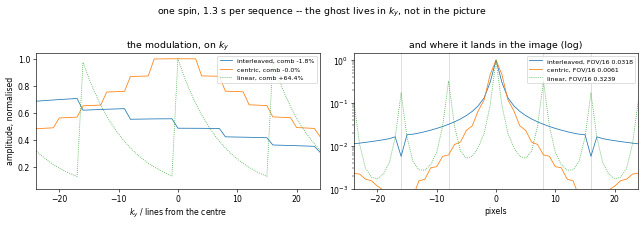

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 3.9))
for name, style in (('fse_interleaved', '-'), ('fse_centric', '-'), ('fse_linear', ':')):
    label = name.replace('fse_', '')
    axes[0].plot(np.arange(NY) - CENTER_LINE, ky_filter[name] / ky_filter[name].max(), style,
                 lw=1.0, label=f'{label}, comb {comb_depth(name):+.1%}')
    axes[1].semilogy(np.arange(NY) - NY // 2, np.maximum(psf[name], 1e-4), style, lw=1.0,
                     label=f'{label}, FOV/16 {psf[name][NY // 2 + 8]:.4f}')
axes[0].set(xlim=(-24, 24), xlabel='$k_y$ / lines from the centre',
            ylabel='amplitude, normalised', title='the modulation, on $k_y$')
axes[0].legend(fontsize=8)
for shift in (8, 16):
    axes[1].axvline(shift, color='0.8', lw=0.8, zorder=0)
    axes[1].axvline(-shift, color='0.8', lw=0.8, zorder=0)
axes[1].set(xlim=(-24, 24), ylim=(1e-3, 1.5), xlabel='pixels',
            title='and where it lands in the image (log)')
axes[1].legend(fontsize=8)
fig.suptitle('one spin, 1.3 s per sequence -- the ghost lives in $k_y$, not in the picture', y=1.02)
fig.tight_layout()

The left panel is `linear`'s sawtooth against two smooth filters; the right is where each of those
lands, with the grey lines marking FOV/8 and FOV/16.

### The same thing on an object

Three 9-shot acquisitions against the BrainWeb slab, one per ordering. Everything above is already
measured, so what these add is *recognition* — what a reader would actually see on a console.

The phantom is a **two-slice** slab rather than `gre_2d/02`'s four. One voxel returns exactly zero
signal, because a slice-select gradient dephases across the slice and a single voxel has nothing to
average over; two is enough for that to be true, and it halves the voxel count and the time.

In [9]:
PHANTOM_URL = ('https://github.com/MRsources/MRzero-Core/raw/main/'
               'documentation/playground_mr0/subject05.npz')
PHANTOM = Path('../data/subject05.npz')

if not PHANTOM.exists():
    PHANTOM.parent.mkdir(parents=True, exist_ok=True)
    print(f'downloading {PHANTOM_URL} -> {PHANTOM} (~19 MB, once)')
    urllib.request.urlretrieve(PHANTOM_URL, PHANTOM)

N_COILS = 8
IMAGED = ('fse_interleaved', 'fse_centric', 'fse_linear')


def coil_ring(nx, ny, nz, n_coils=N_COILS):
    """A ring of `n_coils` surface coils around the object, as complex sensitivities."""
    gx, gy = np.meshgrid(np.linspace(-1, 1, nx), np.linspace(-1, 1, ny), indexing='ij')
    sens = np.stack([
        np.exp(-((gx - 1.5 * np.cos(a)) ** 2 + (gy - 1.5 * np.sin(a)) ** 2) / 1.5)
        * np.exp(1j * np.arctan2(gy - np.sin(a), gx - np.cos(a)))
        for a in np.arange(n_coils) * 2 * np.pi / n_coils
    ]).astype(np.complex64)
    return torch.tensor(np.repeat(sens[:, :, :, None], nz, axis=3))


def add_noise(ksp, mask, sigma, seed=0):
    """Complex Gaussian noise on the *sampled* rows only, circularly symmetric."""
    rng = np.random.default_rng(seed)
    noise = np.zeros_like(ksp)
    shape = (ksp.shape[0], int(mask.sum()), ksp.shape[2])
    noise[:, mask, :] = (sigma / np.sqrt(2)) * (
        rng.standard_normal(shape) + 1j * rng.standard_normal(shape))
    return ksp + noise.astype(np.complex64)


whole = mr0.VoxelGridPhantom.load(PHANTOM).interpolate(NX, NX, 128)
brain_phantom = whole.slices(list(range(64 - NZ // 2, 64 + NZ - NZ // 2)))
brain_phantom.affine[2, 3] = -0.5 * NZ * float(brain_phantom.affine[2, 2])
brain_phantom.coil_sens = coil_ring(NX, NX, NZ)
data = brain_phantom.build()

mid = NZ // 2
t2_map = brain_phantom.T2[:, :, mid].numpy().T
brain = brain_phantom.T1[:, :, mid].numpy().T > 0.2


def replica(image, shift):
    """Signal a replica distance outside the object, relative to inside it.

    Measured where the object is *not*: inside the brain a shifted copy is indistinguishable from
    the brain itself, and outside it there is nothing but the replica and the noise.
    """
    where = (~brain) & (np.roll(brain, shift, axis=0) | np.roll(brain, -shift, axis=0))
    return float(image[where].mean() / image[brain].mean())


print(f'{int(data.PD.numel())} voxels in {NZ} slices, {N_COILS} coils')
raw, sampled, clean, image = {}, {}, {}, {}
if BRAIN_IMAGES:
    slowest = 0.0
    for name in IMAGED:
        began = time.time()
        sampled[name], raw[name] = acquire(name, data)
        slowest = max(slowest, time.time() - began)
        print(f'  {name:16s} {time.time() - began:6.1f} s', flush=True)
    SIGMA = float(rss(ifft2c(raw['fse_interleaved'])).max()) / NOISE_SNR
    for index, name in enumerate(IMAGED):
        # Two reconstructions of each: the ghost is a property of the acquisition, and noise is an
        # additive term on top of it.  At SNR 60 the noise outside the brain is about the size of
        # the replica, so a metric read off the noisy image measures the noise instead.
        clean[name] = rss(ifft2c(raw[name]))
        image[name] = rss(ifft2c(add_noise(raw[name], sampled[name], SIGMA, seed=index)))

    print()
    print(f'{"file":16s} {"FOV/16, 8px":>12s} {"FOV/8, 16px":>12s} {"one spin, FOV/16":>17s}')
    for name in IMAGED:
        print(f'{name:16s} {replica(clean[name], 8):12.4f} {replica(clean[name], 16):12.4f} '
              f'{psf[name][NY // 2 + 8]:17.4f}')
    print()
    print(f'`linear` stands out at FOV/16 on the object and on one spin alike -- '
          f'{replica(clean["fse_linear"], 8) / replica(clean["fse_interleaved"], 8):.0f}x and '
          f'{psf["fse_linear"][NY // 2 + 8] / psf["fse_interleaved"][NY // 2 + 8]:.0f}x '
          f'`interleaved`.')
    print(f'The one-spin measurement costs 1.3 s against the {slowest:.0f} s an image of the same')
    print('sequence takes, which is the argument for measuring on one spin and drawing on a brain')
    print('rather than doing both on a brain.')
else:
    SIGMA = None
    print('BRAIN_IMAGES is False -- no images, and no numbers lost.')

18804 voxels in 2 slices, 8 coils


  fse_interleaved    71.5 s


  fse_centric        53.3 s


  fse_linear         55.6 s



file              FOV/16, 8px  FOV/8, 16px  one spin, FOV/16
fse_interleaved        0.0328       0.0301            0.0318
fse_centric            0.0209       0.0204            0.0061
fse_linear             0.2173       0.1676            0.3239

`linear` stands out at FOV/16 on the object and on one spin alike -- 7x and 10x `interleaved`.
The one-spin measurement costs 1.3 s against the 71 s an image of the same
sequence takes, which is the argument for measuring on one spin and drawing on a brain
rather than doing both on a brain.


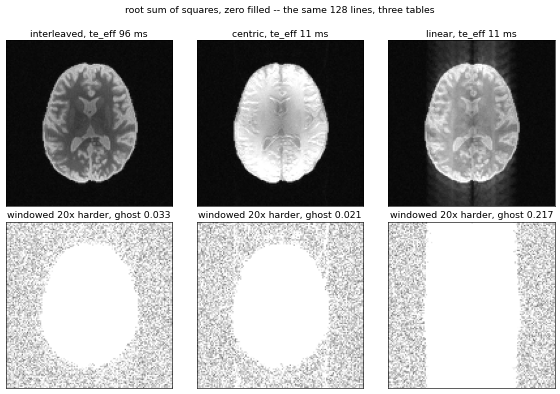

In [10]:
if BRAIN_IMAGES:
    top = 0.8 * max(picture.max() for picture in image.values())
    fig, axes = plt.subplots(2, 3, figsize=(10.4, 7.0))
    for column, name in enumerate(IMAGED):
        label = name.replace('fse_', '')
        axes[0, column].imshow(image[name], origin='lower', cmap='gray', vmin=0, vmax=top)
        axes[0, column].set(title=f'{label}, te_eff {meta[name]["te_eff_s"] * 1e3:.0f} ms',
                            xticks=[], yticks=[])
        # A twentieth of the window, which is where a replica at a few per cent of the object is.
        axes[1, column].imshow(image[name], origin='lower', cmap='gray', vmin=0, vmax=top / 20)
        axes[1, column].set(title=f'windowed 20x harder, ghost '
                                  f'{replica(clean[name], 8):.3f}', xticks=[], yticks=[])
    fig.suptitle('root sum of squares, zero filled -- the same 128 lines, three tables', y=1.0)
    fig.tight_layout()

Read the bottom row. `linear` carries its own replica at half the head's width, and no run-in
touches it: that one is the table. `interleaved` and `centric` are clean, and `centric` is visibly
the softest — its point-spread width showing up as a picture.

The top row is the contrast: `interleaved` at te_eff = 96 ms is the T2-weighted image the protocol
was after, and `centric` at 10.7 ms is proton-density weighted — the same sequence, the same lines,
a different table.

---
## 5. HASTE — one shot, and what it costs

72 echoes and `partial_fourier = 0.625`: 80 of 128 samples along the readout, so the missing part of
k-space is a band of **columns** and it has to come from the conjugate symmetry of the object.

**This is the one section that needs a brain**, because conjugate symmetry is a property of an
object and a point has none. It is also the cheap one: a single shot of 73 repetitions costs about
5 s, against 173 s for a 9-shot train.

Zero-filling leaves those columns at exactly zero, which is a blur along the readout. **POCS**
estimates the phase from the *symmetric* part of k-space — the columns measured on both sides of the
centre — then iterates: transform, impose that phase, transform back, restore the measured columns.

In [11]:
def pocs(ksp, columns, *, iterations=12):
    """Partial-Fourier reconstruction by projection onto convex sets, per coil."""
    symmetric = columns & columns[::-1]
    window = np.hanning(int(symmetric.sum()) + 2)[1:-1][None, :]
    low = np.zeros_like(ksp)
    low[:, :, symmetric] = ksp[:, :, symmetric] * window
    phase = np.exp(1j * np.angle(ifft2c(low)))

    estimate = ifft2c(ksp)
    for _ in range(iterations):
        estimate = np.abs(estimate) * phase
        grid = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(estimate, axes=(-2, -1)),
                                           norm='ortho'), axes=(-2, -1))
        grid[:, :, columns] = ksp[:, :, columns]
        estimate = ifft2c(grid)
    return estimate


def unmeasured_energy(picture, columns):
    """The fraction of a reconstruction's k-space energy in the columns nobody measured."""
    grid = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(picture)))
    return float((np.abs(grid[:, ~columns]) ** 2).sum() / (np.abs(grid) ** 2).sum())


sampled_rows, haste_raw = acquire('haste', data)
if SIGMA is None:                       # BRAIN_IMAGES was off, so nothing has set the noise yet
    SIGMA = float(rss(ifft2c(haste_raw)).max()) / NOISE_SNR
haste_ksp = add_noise(haste_raw, sampled_rows, SIGMA, seed=9)

start = NX // 2 - int(meta['haste']['pre_echo_samples'])
haste_columns = np.zeros(NX, dtype=bool)
haste_columns[start:start + int(meta['haste']['num_samples'])] = True

haste_zf = rss(ifft2c(haste_ksp))
haste_pocs = rss(pocs(haste_ksp, haste_columns))

print(f'{int(meta["haste"]["num_samples"])} of {NX} readout samples (columns {start} ... '
      f'{start + int(meta["haste"]["num_samples"]) - 1}), {int(sampled_rows.sum())} of {NY} '
      f'lines, one excitation')
print(f'te_eff {meta["haste"]["te_eff_s"] * 1e3:.1f} ms, last echo '
      f'{int(meta["haste"]["echoes"]) * meta["haste"]["echo_spacing_s"] * 1e3:.0f} ms after it')
print()
print(f'{"":24s} {"PSF FWHM":>10s} {"blur":>8s}   along the phase-encode direction')
for tag, name in (('16 echoes, interleaved', 'fse_interleaved'), ('72 echoes, HASTE', 'haste')):
    print(f'{tag:24s} {fwhm_px(psf[name]):9.2f}px {fwhm_px(psf[name]) * FOV_MM[1] / NY:7.2f}mm')
print()
print(f'{"reconstruction":24s} {"k-space recovered":>18s} {"signal / background":>20s}')
for tag, picture in (('zero filled', haste_zf), ('POCS', haste_pocs)):
    corner = np.r_[picture[:12, :12].ravel(), picture[-12:, -12:].ravel()]
    print(f'{tag:24s} {unmeasured_energy(picture, haste_columns):18.4f} '
          f'{picture[brain].mean() / corner.std():20.1f}')
print()
print('POCS is the trade it looks like: it recovers the readout-direction detail that zero filling')
print('throws away, out of the conjugate symmetry of the object, and it pays for that in noise')
print('where nothing was measured.  Neither can touch the blur in the column above it: 72 echo')
print('spacings of T2 decay spread across ky is in the data, and it is why HASTE is a breath-hold')
print('sequence rather than a general-purpose one.')

80 of 128 readout samples (columns 48 ... 127), 72 of 128 lines, one excitation
te_eff 95.6 ms, last echo 765 ms after it

                           PSF FWHM     blur   along the phase-encode direction
16 echoes, interleaved        1.43px    2.86mm
72 echoes, HASTE              9.49px   18.98mm

reconstruction            k-space recovered  signal / background
zero filled                          0.0093                 83.8
POCS                                 0.0294                 67.1

POCS is the trade it looks like: it recovers the readout-direction detail that zero filling
throws away, out of the conjugate symmetry of the object, and it pays for that in noise
where nothing was measured.  Neither can touch the blur in the column above it: 72 echo
spacings of T2 decay spread across ky is in the data, and it is why HASTE is a breath-hold
sequence rather than a general-purpose one.


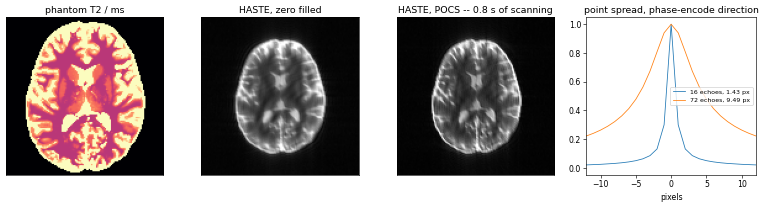

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(13.8, 3.8))
axes[0].imshow(t2_map * 1e3, origin='lower', cmap='magma', vmin=0, vmax=150)
axes[0].set(title='phantom T2 / ms', xticks=[], yticks=[])
axes[1].imshow(haste_zf, origin='lower', cmap='gray', vmin=0, vmax=0.85 * haste_zf.max())
axes[1].set(title='HASTE, zero filled', xticks=[], yticks=[])
axes[2].imshow(haste_pocs, origin='lower', cmap='gray', vmin=0, vmax=0.85 * haste_pocs.max())
axes[2].set(title='HASTE, POCS -- 0.8 s of scanning', xticks=[], yticks=[])
for name, label in (('fse_interleaved', '16 echoes'), ('haste', '72 echoes')):
    axes[3].plot(np.arange(NY) - NY // 2, psf[name], lw=1.0,
                 label=f'{label}, {fwhm_px(psf[name]):.2f} px')
axes[3].set(xlim=(-12, 12), xlabel='pixels', title='point spread, phase-encode direction')
axes[3].legend(fontsize=8)
fig.tight_layout()

---
## What this notebook established

| | |
|---|---|
| a perfect train's envelope is **exactly** $e^{-t/T_2}$ | measured at the sequence's own echo spacing, which is what makes the echo index a clean T2 filter across $k_y$ |
| an imperfect refocusing angle costs signal **per echo** | `B1 = 0.8` turns an 80 ms decay into a 45.7 ms one — the trade a reduced-flip SAR-limited train makes |
| an ordering is a **filter across $k_y$**, so it is a point-spread function | measured from one spin through the written `.seq`, per ordering, in pixels |
| **contrast and blurring are different knobs** | turbo factor moves the width; echo index moves the tissue ratio. Both live in `segments` |
| a scattered table ghosts at **FOV/16**, and no run-in helps | that one is the table, which is why `01` warns about it |
| the run-in holds shot 0's lines to the rest of the scan | the comb off $k_y$ is what says so, and `01` builds every multi-shot file with it |
| HASTE is a whole image in **0.8 s**, one shot, and therefore no shot ghost at all | what it pays is the point spread, which is in the data |
| **a ghost is measurable on one spin** | it is a modulation of $k_y$, and a point object's k-space *is* that modulation — 1.3 s instead of 173 s, and no reconstruction in the way |
| the **CPMG phase relation is not measured here** | MRzero's model is insensitive to it, named rather than worked around — as is the `z` crusher balance in [`../se_2d/02`](../se_2d/02_simulate_and_reconstruct.ipynb) |

Two modules came out of this pair and into the package — `Refocusing`, and `prephase` on
`CartesianLine`. `SE2D` and `FSE2D` stayed in their notebooks, with one consumer each.